<a href="https://colab.research.google.com/github/luxon7/credit-card-fraud-detection-projekat/blob/main/Projekat_Duboko_Ucenje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Prvih 5 redova dataseta ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   



/tmp/ipykernel_4734/279956206.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Dark2')


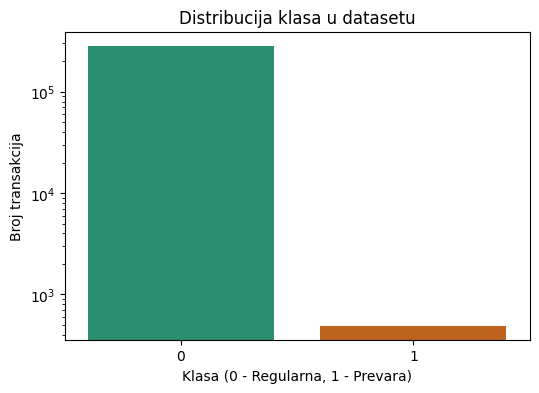


--- Statistika iznosa za regularne transakcije ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Statistika iznosa za prevare ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [ ]:
# Ucitavanje biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Učitavanje dataseta
df = pd.read_csv('creditcard.csv')

# Prikaz prvih nekoliko redova
print("--- Prvih 5 redova dataseta ---")
print(df.head())

print("\n--- Distribucija klasa (0 = Regularna, 1 = Prevara) ---")
print(df['Class'].value_counts())

print("\n--- Procentualni udeo prevara ---")
print(df['Class'].value_counts(normalize=True) * 100)

# Vizuelizacija debalansa
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Dark2')
plt.title('Distribucija klasa u datasetu')
plt.xlabel('Klasa (0 - Regularna, 1 - Prevara)')
plt.ylabel('Broj transakcija')
plt.yscale('log') # Logaritamska skala jer je razlika ogromna
plt.show()


print("\n--- Statistika iznosa za regularne transakcije ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Statistika iznosa za prevare ---")
print(df[df['Class'] == 1]['Amount'].describe())

In [ ]:
# Import klasa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kopija dataseta
data = df.copy()

# Inicijalizuja StandardScaler-a (prosek 0, a standardna devijacija 1)
scaler = StandardScaler()

# Skaliranje kolona Amount i Time, jer njihove vrednosti odskacu
data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

# Brisanje starih kolona
data = data.drop(['Time', 'Amount'], axis=1)

# X su svi ulazni podaci (karakteristike transakcije)
X = data.drop('Class', axis=1)

# y je target (0 ili 1)
y = data['Class']

# Podela na train i test (80% train 20% test)
# random_state=42 osigurava da svaki put dobijemo istu podelu podataka
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Dimenzije podataka nakon podele ---")
print(f"Trening set (X_train): {X_train.shape}")
print(f"Test set (X_test): {X_test.shape}")

print("\n--- Provera debalansa u Trening setu ---")
print(y_train.value_counts(normalize=True) * 100)

--- Dimenzije podataka nakon podele ---
Trening set (X_train): (227845, 30)
Test set (X_test): (56962, 30)

--- Provera debalansa u Trening setu ---
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

#funkcija za evaluaciju modela
def evaluacija_modela(model, X_test, y_test, ime_modela):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\n=======================================================")
    print(f"   KLASIFIKACIONI IZVEŠTAJ ZA: {ime_modela}")
    print(f"=======================================================")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Regularna (0)', 'Prevara (1)'],
                yticklabels=['Regularna (0)', 'Prevara (1)'])
    plt.title(f'Matrica konfuzije - {ime_modela}')
    plt.ylabel('Stvarna klasa')
    plt.xlabel('Predviđena klasa')
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    return tp, fn, fp, tn

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trening Modela 1 u toku...

   KLASIFIKACIONI IZVEŠTAJ ZA: Model 1 (Baseline)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.73      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.87      0.89     56962
weighted avg       1.00      1.00      1.00     56962



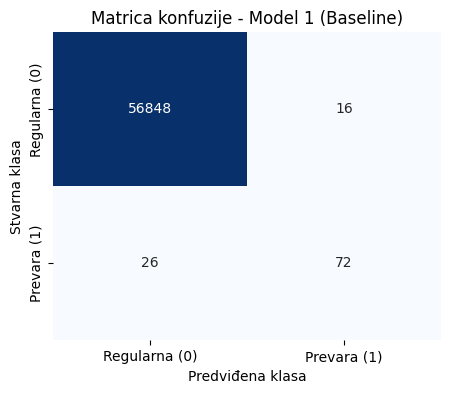

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

# 1. Pravljenje arhitekture (Čista mreža)
model_1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# TRENING BEZ CLASS WEIGHTS
print("Trening Modela 1 u toku...")
history_1 = model_1.fit(X_train, y_train, epochs=5, batch_size=2048, validation_split=0.1, verbose=0)

# Evaluacija
tp1, fn1, fp1, tn1 = evaluacija_modela(model_1, X_test, y_test, "Model 1 (Baseline)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trening Modela 2 u toku...

   KLASIFIKACIONI IZVEŠTAJ ZA: Model 2 (Težinski)
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



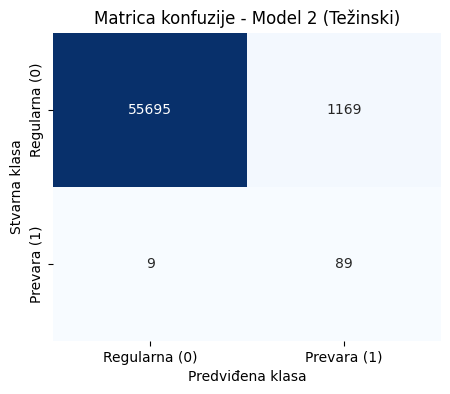

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Računanje težina klasa
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Uvodimo težine u trening
model_2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# TRENING SA CLASS WEIGHTS
print("Trening Modela 2 u toku...")
history_2 = model_2.fit(X_train, y_train, epochs=5, batch_size=2048, validation_split=0.1, class_weight=class_weight_dict, verbose=0)

# Evaluacija
tp2, fn2, fp2, tn2 = evaluacija_modela(model_2, X_test, y_test, "Model 2 (Težinski)")

Trening Modela 3 u toku...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4762 - precision: 0.0035 - recall: 0.8797 - val_loss: 0.4622 - val_precision: 0.0307 - val_recall: 0.9778
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2762 - precision: 0.0264 - recall: 0.9026 - val_loss: 0.2456 - val_precision: 0.1005 - val_recall: 0.9333
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2074 - precision: 0.0573 - recall: 0.8968 - val_loss: 0.1710 - val_precision: 0.0848 - val_recall: 0.9556
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1724 - precision: 0.0506 - recall: 0.9026 - val_loss: 0.1314 - val_precision: 0.0841 - val_recall: 0.9778
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1622 - precision: 0.0488 - recall: 0.9112 - val_loss: 0.1048 - val_precision: 0.0953 - val_recall: 0.9556
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1517 - precision: 0.0600 - recall: 0.8968 - val_loss: 0.1041 - val_precision: 0.0821 - val_recall: 0.9778
Epo

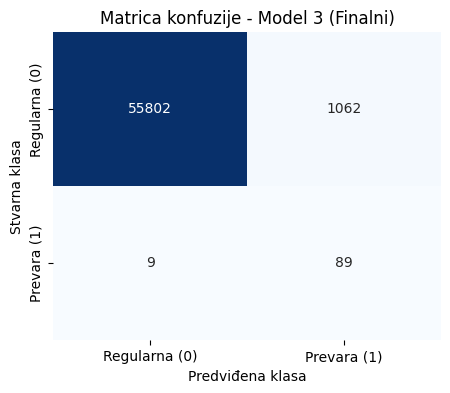

In [ ]:
# Arhitektura sa Dropout-om i Weight Decay-om
model_3 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Regularizacija 1
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=1e-4), # Regularizacija 2
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# TRENING SA CLASS WEIGHTS I REGULARIZACIJOM
print("Trening Modela 3 u toku...")
history_3 = model_3.fit(X_train, y_train, epochs=10, batch_size=2048, validation_split=0.1, class_weight=class_weight_dict, verbose=1)

# Evaluacija
tp3, fn3, fp3, tn3 = evaluacija_modela(model_3, X_test, y_test, "Model 3 (Finalni)")

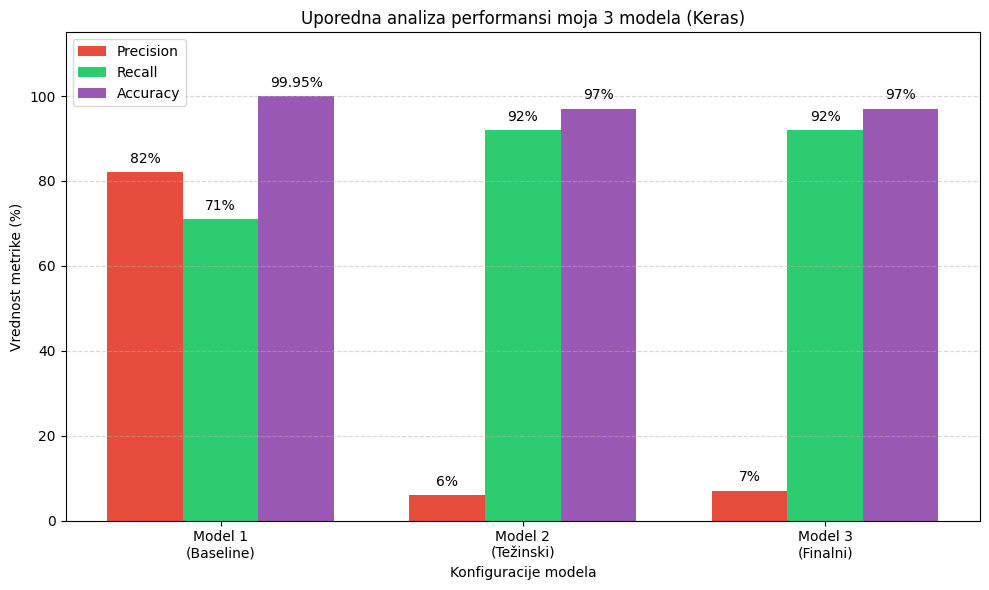

In [1]:
import numpy as np
import matplotlib.pyplot as plt

modeli = ['Model 1\n(Baseline)', 'Model 2\n(Težinski)', 'Model 3\n(Finalni)']

precisions = [0.82 * 100, 0.06 * 100, 0.07 * 100]
recalls = [0.71 * 100, 0.92 * 100, 0.92 * 100]
accuracies = [0.9995 * 100, 0.97 * 100, 0.97 * 100]

x = np.arange(len(modeli))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precisions, width, label='Precision', color='#e74c3c')
plt.bar(x, recalls, width, label='Recall', color='#2ecc71')
plt.bar(x + width, accuracies, width, label='Accuracy', color='#9b59b6')

plt.xlabel('Konfiguracije modela')
plt.ylabel('Vrednost metrike (%)')
plt.title('Uporedna analiza performansi moja 3 modela (Keras)')
plt.xticks(x, modeli)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')


for i in range(len(modeli)):
    if i == 0:
        plt.text(i - width, precisions[i] + 1.5, f'{precisions[i]:.0f}%', ha='center', va='bottom')
        plt.text(i, recalls[i] + 1.5, f'{recalls[i]:.0f}%', ha='center', va='bottom')
        plt.text(i + width, accuracies[i] + 1.5, f'{accuracies[i]:.2f}%', ha='center', va='bottom')
    else:
        plt.text(i - width, precisions[i] + 1.5, f'{precisions[i]:.0f}%', ha='center', va='bottom')
        plt.text(i, recalls[i] + 1.5, f'{recalls[i]:.0f}%', ha='center', va='bottom')
        plt.text(i + width, accuracies[i] + 1.5, f'{accuracies[i]:.0f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

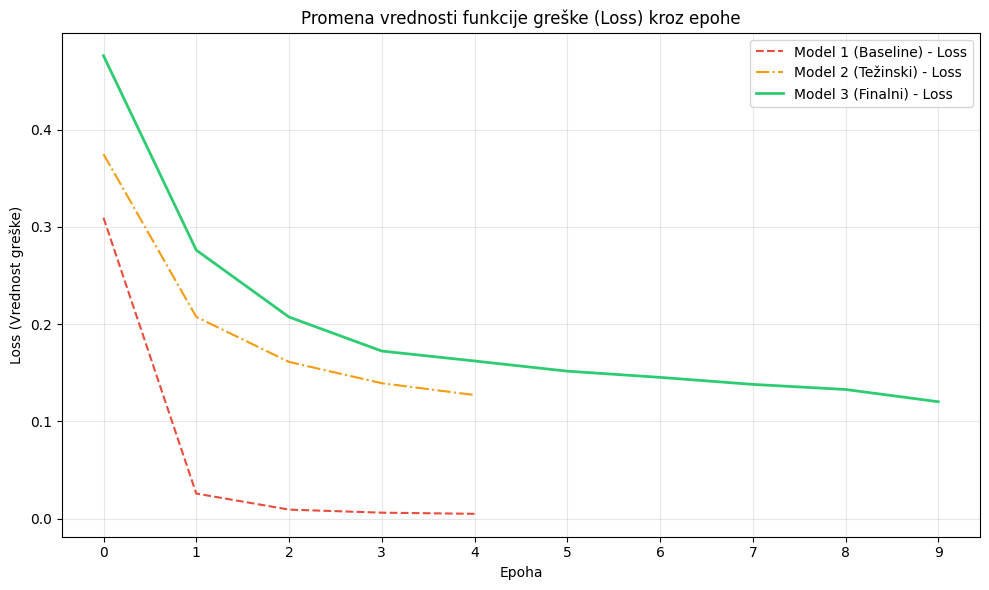

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Iscrtavanje krive za Model 1
plt.plot(history_1.history['loss'], label='Model 1 (Baseline) - Loss', color='#e74c3c', linestyle='--')

# Iscrtavanje krive za Model 2
plt.plot(history_2.history['loss'], label='Model 2 (Težinski) - Loss', color='#f39c12', linestyle='-.')

# Iscrtavanje krive za Model 3
plt.plot(history_3.history['loss'], label='Model 3 (Finalni) - Loss', color='#2ecc71', linewidth=2)

plt.title('Promena vrednosti funkcije greške (Loss) kroz epohe')
plt.xlabel('Epoha')
plt.ylabel('Loss (Vrednost greške)')
plt.xticks(range(10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()